# Lab 01 — Cotizaciones Optimas de un Formador de Mercado

**Modelo de Copeland y Galai (1983)** — Microestructura y Sistemas de Trading, ITESO, Otono 2026. Equipo 2.

Este notebook **solo importa, llama y grafica**. Toda la logica del modelo y de la
simulacion vive en `src/`; aqui no se define ninguna formula. Para reproducir todo
desde la linea de comandos: `python main.py`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ / "src"))

from model import (Parametros, SEED, optimizar, prob_ejecucion, sensibilidad,
                   spread_monopolista, utilidad_esperada, perdida_informados,
                   ganancia_liquidez)
from simulation import (REGIMENES_FIJOS, monte_carlo, resumen_monte_carlo,
                        simular_regimenes, tabla_regimenes)
import plots

%matplotlib inline
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

par = Parametros()
par

Parametros(S0=19.9, K=60, lam=3.0, pi_I=0.4, alpha=0.5, beta=0.08)

## 1. Parametros del caso base

Fijos para todos los equipos. `P ~ Erlang(K=60, lambda=3)` tiene media `K/lambda = 20`
y desviacion estandar `sqrt(K)/lambda = 2.58`, asi que `S0 = 19.90` esta justo por
debajo del valor esperado del activo.

In [2]:
P = par.distribucion()
resumen_par = pd.Series({
    "S0": par.S0, "K": par.K, "lambda": par.lam,
    "E[P]": P.mean(), "sd(P)": P.std(),
    "pi_I": par.pi_I, "pi_L": par.pi_L,
    "alpha": par.alpha, "beta": par.beta,
    "s con demanda nula (alpha/beta)": par.s_max,
    "SEED": SEED,
})
resumen_par

S0                                19.9000
K                                 60.0000
lambda                             3.0000
E[P]                              20.0000
sd(P)                              2.5820
pi_I                               0.4000
pi_L                               0.6000
alpha                              0.5000
beta                               0.0800
s con demanda nula (alpha/beta)    6.2500
SEED                              42.0000
dtype: float64

## 2. Cotizaciones optimas

Las integrales de perdida se resuelven con `scipy.integrate.quad` y la maximizacion
de `Pi(A,B)` con `scipy.optimize.minimize` (L-BFGS-B con cotas y multiarranque),
sujeta a `B in (0, S0]` y `A in [S0, inf)`.

In [3]:
opt = optimizar(par)
pd.Series(opt).round(4)

bid                  16.4517
ask                  23.4277
spread                6.9760
utilidad              0.8403
semi_spread_ask       3.5277
semi_spread_bid       3.4483
ganancia_liquidez     0.9247
perdida_informados    0.0844
dtype: float64

In [4]:
print(f"Bid optimo              = {opt['bid']:.2f}")
print(f"Ask optimo              = {opt['ask']:.2f}")
print(f"Spread optimo           = {opt['spread']:.2f}")
print(f"Utilidad esperada/trade = {opt['utilidad']:.2f}")

Bid optimo              = 16.45
Ask optimo              = 23.43
Spread optimo           = 6.98
Utilidad esperada/trade = 0.84


### Figura 1 — Probabilidad de ejecucion contra el spread

Se marca el punto donde la demanda no informada se anula, `s = alpha/beta = 6.25`.
Mas alla de ahi el dealer no tiene flujo del cual ganar.

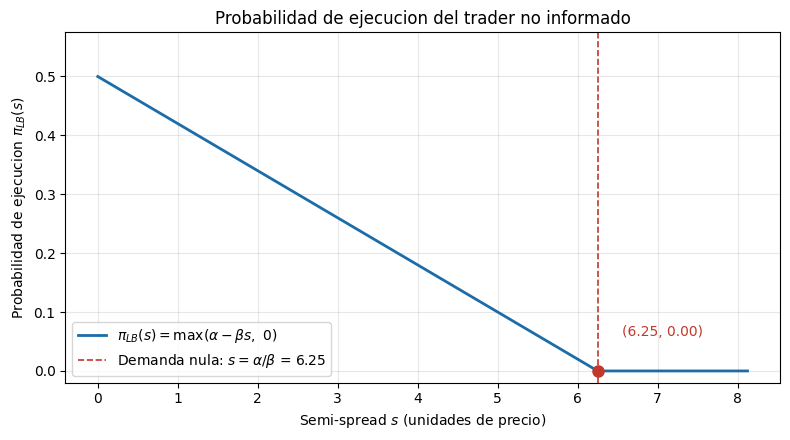

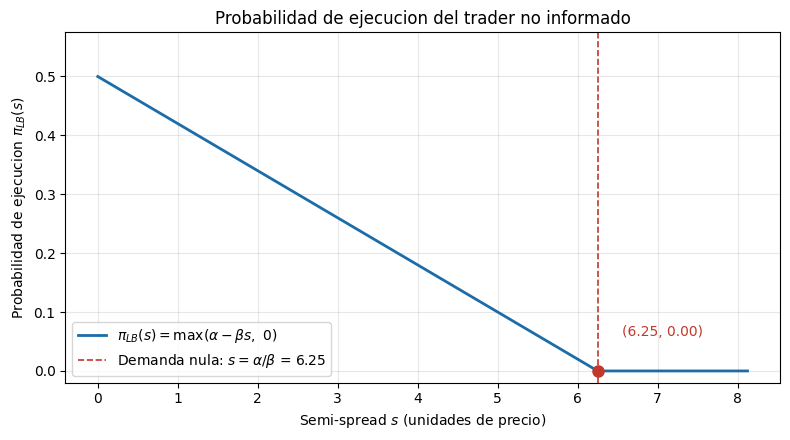

In [5]:
fig = plots.figura_prob_ejecucion(par)
fig

### El trade-off del spread

Ampliar el spread reduce la perdida frente a informados (`L`) pero tambien espanta
al flujo no informado (`G`). El optimo es el punto donde el ahorro marginal en `L`
deja de compensar la perdida marginal de flujo.

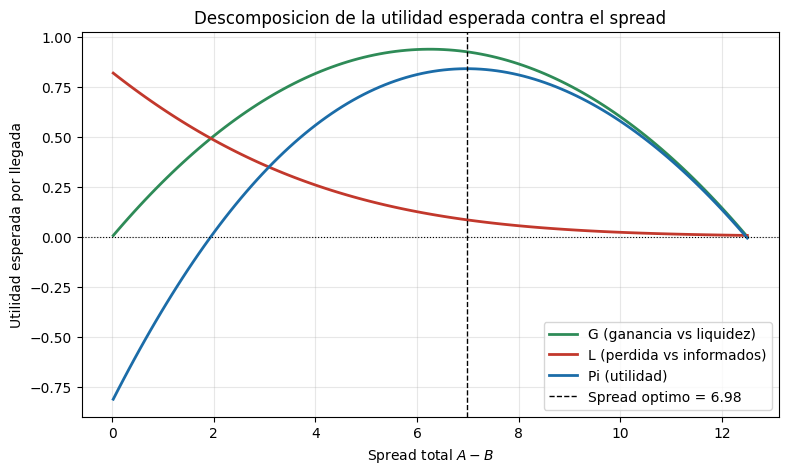

In [6]:
ds = np.linspace(0.01, par.s_max, 120)
curva = pd.DataFrame({
    "spread": 2 * ds,
    "G (ganancia vs liquidez)": [ganancia_liquidez(par.S0 + d, par.S0 - d, par) for d in ds],
    "L (perdida vs informados)": [perdida_informados(par.S0 + d, par.S0 - d, par) for d in ds],
    "Pi (utilidad)": [utilidad_esperada(par.S0 + d, par.S0 - d, par) for d in ds],
}).set_index("spread")

ax = curva.plot(figsize=(9, 5), lw=2,
                color=["#2e8b57", "#c2382c", "#1b6ca8"])
ax.axvline(opt["spread"], ls="--", color="black", lw=1,
           label=f"Spread optimo = {opt['spread']:.2f}")
ax.axhline(0, color="black", lw=0.8, ls=":")
ax.set_title("Descomposicion de la utilidad esperada contra el spread")
ax.set_xlabel("Spread total $A - B$")
ax.set_ylabel("Utilidad esperada por llegada")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## 3. Simulacion de 10,000 trades

Tres regimenes: el optimo recien calculado, el estrecho (19.75, 20.05) y el amplio
(18.40, 21.40). Los tres se corren con la **misma semilla**, asi que comparten la
secuencia de tipos de trader y de valores `P`: las diferencias de P&L vienen del
spread y no del ruido.

In [7]:
regimenes = {"optimo": {"bid": opt["bid"], "ask": opt["ask"]}, **REGIMENES_FIJOS}
sims = simular_regimenes(regimenes, 10_000, par, SEED)

tabla_regimenes(sims, regimenes).round(2)

,bid,ask,spread,pnl_total,pnl_por_trade,trades_ejecutados,inventario_final,inventario_max_abs,pnl_vs_informados,pnl_vs_liquidez
optimo,16.4500,23.4300,6.9800,"20,023.8400",3.0000,"6,679.0000",-35.0000,97.0000,-897.9700,"20,921.8100"
estrecho,19.7500,20.0500,0.3000,"-6,737.3200",-0.6900,"9,809.0000",-51.0000,117.0000,"-7,782.6800","1,045.3600"
amplio,18.4000,21.4000,3.0000,"5,396.8500",0.6600,"8,215.0000",1.0000,88.0000,"-3,702.6100","9,099.4600"


In [8]:
# Como se ve una corrida por dentro: las primeras llegadas del regimen estrecho
sims["estrecho"].head(10)

,informado,compra,ejecutado,valor_P,pnl,cambio_inventario,pnl_acumulado,inventario
0,False,True,True,15.4231,4.6269,-1,4.6269,-1
1,False,False,True,23.0922,3.3422,1,7.9691,0
2,False,True,True,21.2615,-1.2115,-1,6.7576,-1
3,False,True,True,20.5183,-0.4683,-1,6.2894,-2
4,True,True,True,21.5351,-1.4851,-1,4.8042,-3
5,False,False,True,15.5395,-4.2105,1,0.5937,-2
6,False,True,True,19.3499,0.7001,-1,1.2938,-3
7,False,False,True,18.2630,-1.4870,1,-0.1933,-2
8,True,True,True,20.3053,-0.2553,-1,-0.4486,-3
9,False,True,True,20.4011,-0.3511,-1,-0.7996,-4


### Figura 2 — P&L acumulado

El regimen estrecho se hunde de forma monotona: 0.15 por lado no alcanza para
pagar lo que le cuestan los informados.

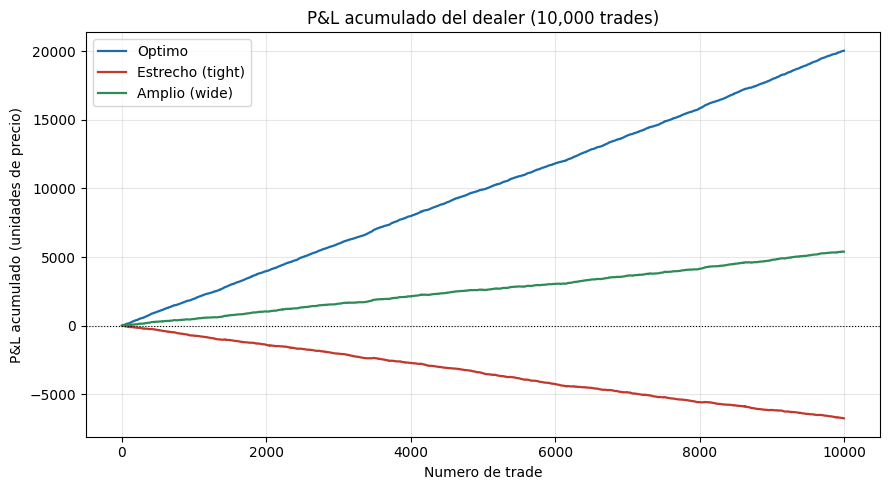

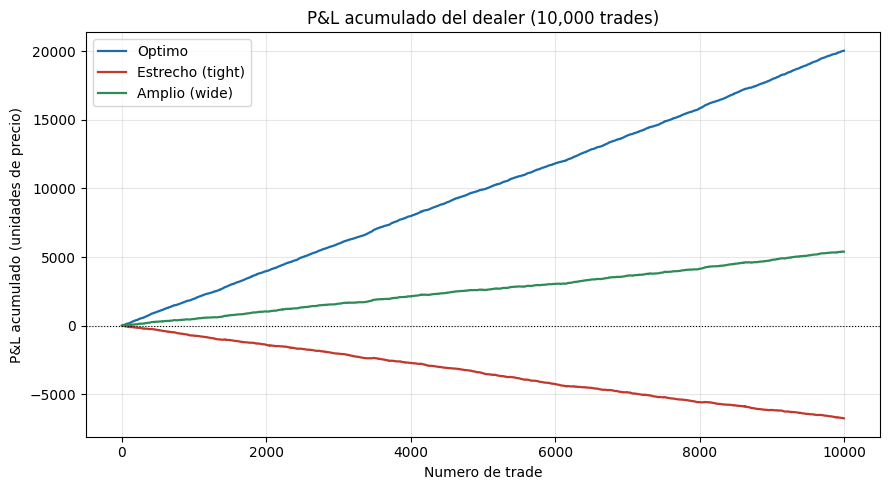

In [9]:
fig = plots.figura_pnl_acumulado(sims)
fig

### Figura 3 — Inventario acumulado

El regimen estrecho acumula el mayor desbalance. No es casualidad: es el que mas
trades informados ejecuta, y los informados llegan todos del mismo lado a la vez
porque su direccion esta correlacionada con el valor verdadero. **El desbalance de
inventario es el rastro de la seleccion adversa.**

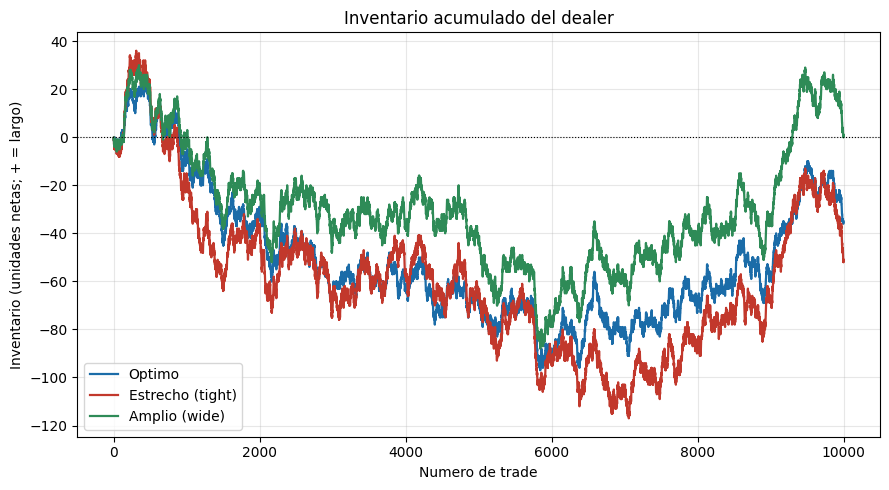

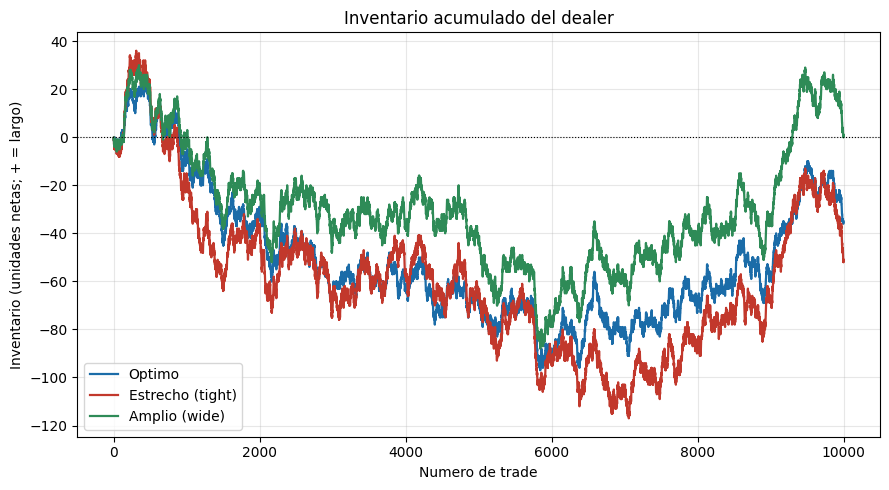

In [10]:
fig = plots.figura_inventario(sims)
fig

In [11]:
# De donde sale el P&L de cada regimen: informados contra liquidez
desglose = pd.DataFrame({
    n: {"vs informados": d.loc[d["informado"], "pnl"].sum(),
        "vs liquidez":   d.loc[~d["informado"], "pnl"].sum(),
        "total":         d["pnl"].sum()}
    for n, d in sims.items()
}).T
desglose.round(2)

,vs informados,vs liquidez,total
optimo,-897.9700,"20,921.8100","20,023.8400"
estrecho,"-7,782.6800","1,045.3600","-6,737.3200"
amplio,"-3,702.6100","9,099.4600","5,396.8500"


## 4. Analisis de Monte Carlo

1,000 corridas independientes de 1,000 trades cada una, por regimen. Cada corrida
usa su propio generador derivado de `SEED` con `SeedSequence.spawn`, asi que son
independientes entre si y el resultado es reproducible.

In [12]:
pnl_mc = {n: monte_carlo(q["bid"], q["ask"], 1_000, 1_000, par, SEED)
          for n, q in regimenes.items()}

pd.DataFrame({n: resumen_monte_carlo(p) for n, p in pnl_mc.items()}).T.round(2)

,pnl_promedio,pnl_desv_estandar,prob_perdida
optimo,"2,012.1300",81.6100,0.0000
estrecho,-672.4100,74.6600,1.0000
amplio,543.7200,74.4800,0.0000


### Figura 4 — Distribucion del P&L final

El regimen estrecho no solo pierde en promedio: **su distribucion completa esta a
la izquierda de cero**. La probabilidad de perdida es 1.000, ni una sola de las
1,000 corridas termino en positivo.

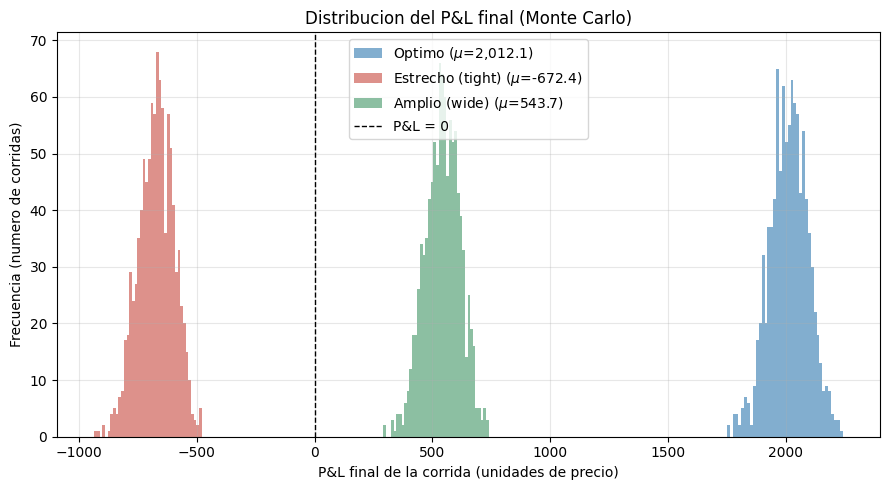

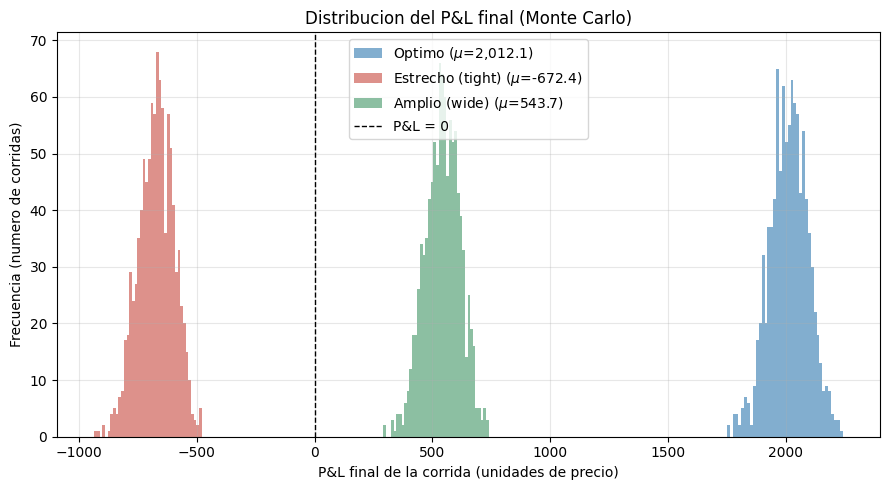

In [13]:
fig = plots.figura_histograma_mc(pnl_mc)
fig

## 5. Analisis de sensibilidad

Se repite la optimizacion para `pi_I in {0.1, 0.4, 0.7}` y se compara contra la
prediccion teorica del caso sin informados.

In [14]:
sens = sensibilidad([0.1, 0.4, 0.7], par)
sens[["bid", "ask", "spread", "utilidad"]].round(4)

,bid,ask,spread,utilidad
pi_I,,,,
0.1000,16.7088,23.1065,6.3977,1.3787
0.4000,16.4517,23.4277,6.9760,0.8403
0.7000,16.0070,24.0008,7.9939,0.3366


In [15]:
# Anclaje teorico: con pi_I = 0 el optimo tiene solucion cerrada
s_teorico = spread_monopolista(par)
sin_inf = optimizar(Parametros(pi_I=0.0))

print(f"Teorico   : semi-spread alpha/(2 beta) = {s_teorico:.4f}"
      f"  ->  spread total alpha/beta = {2 * s_teorico:.4f}")
print(f"Numerico  : bid = {sin_inf['bid']:.4f}, ask = {sin_inf['ask']:.4f}, "
      f"spread = {sin_inf['spread']:.4f}")
print(f"\nEl spread de {2 * s_teorico:.2f} es el PISO: la parte del spread que existe")
print("por poder de mercado y no por informacion. Lo que excede ese piso es la")
print("componente de seleccion adversa:")
for pi_I, fila in sens.iterrows():
    print(f"  pi_I = {pi_I:.1f}  ->  spread {fila['spread']:.2f}  "
          f"(componente de seleccion adversa: {fila['spread'] - 2 * s_teorico:.2f})")

Teorico   : semi-spread alpha/(2 beta) = 3.1250  ->  spread total alpha/beta = 6.2500
Numerico  : bid = 16.7750, ask = 23.0250, spread = 6.2500

El spread de 6.25 es el PISO: la parte del spread que existe
por poder de mercado y no por informacion. Lo que excede ese piso es la
componente de seleccion adversa:
  pi_I = 0.1  ->  spread 6.40  (componente de seleccion adversa: 0.15)
  pi_I = 0.4  ->  spread 6.98  (componente de seleccion adversa: 0.73)
  pi_I = 0.7  ->  spread 7.99  (componente de seleccion adversa: 1.74)


### Figura 5 — Spread optimo contra `pi_I`

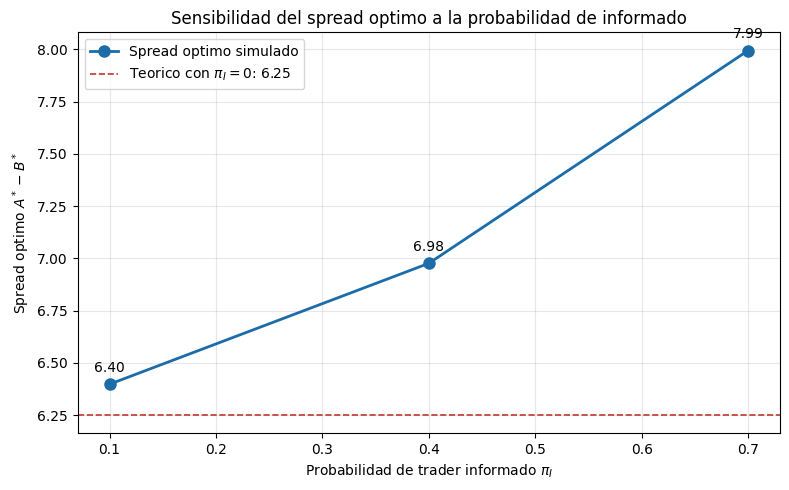

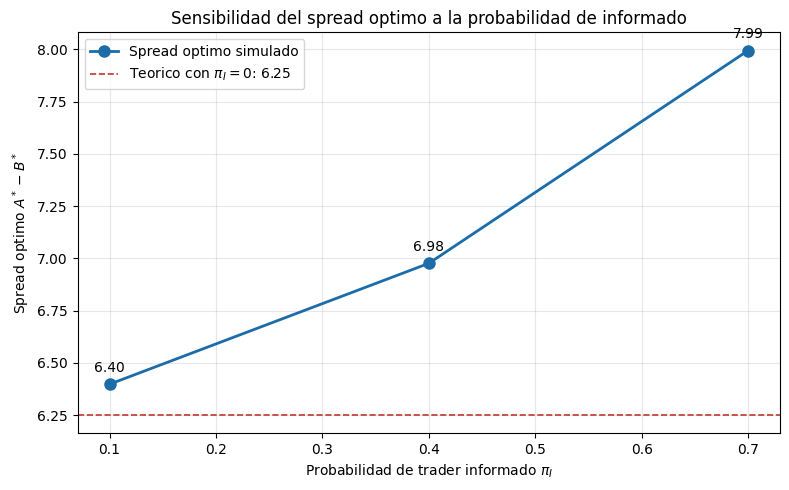

In [16]:
fig = plots.figura_sensibilidad(sens, par)
fig

## 6. Advertencia de interpretacion

La simulacion **fuerza la ejecucion de un trade de liquidez en cada iteracion**, que
es lo que pide el enunciado. Eso significa que las cifras de P&L son **rentabilidad
por trade, no por unidad de tiempo**: al forzar la ejecucion se elimina el castigo
que un spread amplio deberia recibir por no ejecutarse casi nunca.

La celda siguiente cuantifica el sesgo con nuestros propios numeros.

In [17]:
prob_ejec = pd.DataFrame({
    n: {"spread": q["ask"] - q["bid"],
        "P(ejecucion) lado ask": float(prob_ejecucion(q["ask"] - par.S0, par.alpha, par.beta)),
        "P(ejecucion) lado bid": float(prob_ejecucion(par.S0 - q["bid"], par.alpha, par.beta))}
    for n, q in regimenes.items()
}).T
prob_ejec.round(4)

,spread,P(ejecucion) lado ask,P(ejecucion) lado bid
optimo,6.9760,0.2178,0.2241
estrecho,0.3000,0.4880,0.4880
amplio,3.0000,0.3800,0.3800


In [18]:
# Sin forzar la ejecucion, el P&L medio por LLEGADA converge a la utilidad teorica.
# Es la validacion cruzada entre el modelo analitico (quad + minimize) y el simulador.
from simulation import simular_trades

libre = simular_trades(opt["bid"], opt["ask"], 200_000, par,
                       np.random.default_rng(SEED), forzar_ejecucion=False)

print(f"Utilidad teorica  Pi(A*,B*)  = {opt['utilidad']:.4f}")
print(f"P&L medio simulado por llegada = {libre['pnl'].mean():.4f}")
print(f"Trades ejecutados: {libre['ejecutado'].sum():,} de {len(libre):,} "
      f"({libre['ejecutado'].mean():.1%})")

Utilidad teorica  Pi(A*,B*)  = 0.8403
P&L medio simulado por llegada = 0.8404
Trades ejecutados: 67,081 de 200,000 (33.5%)


## Conclusiones

1. **El spread optimo es 6.98** (bid 16.45, ask 23.43), con utilidad esperada de
   0.84 por llegada.
2. **El regimen estrecho pierde dinero con probabilidad 1.000.** Cobra 0.088 de
   ganancia esperada frente a la liquidez y paga 0.764 de seleccion adversa.
3. **El costo de seleccion adversa cae 89% al pasar de spread 0.30 a 6.98**, pero
   el optimo no esta donde `L` es minima: ampliar demasiado mata el flujo.
4. **El spread optimo crece de forma monotona en `pi_I`** (6.25 -> 6.40 -> 6.98 -> 7.99),
   tal como predice la teoria, y el caso `pi_I = 0` reproduce exactamente la
   solucion cerrada del monopolista.
5. **El regimen estrecho acumula el mayor desbalance de inventario** (117 unidades),
   porque es el que mas flujo informado ejecuta.

Las respuestas completas a las cinco preguntas de analisis estan en el `README.md`.